In [22]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier


In [2]:
# 2. Load dataset
df = pd.read_csv(r"C:\Users\choud\Downloads\ml-with-python-course-project\train.csv") 

In [3]:
# Drop irrelevant column
df.drop("sl_no", axis=1, inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          215 non-null    int64  
 1   ssc_p           215 non-null    float64
 2   ssc_b           215 non-null    object 
 3   hsc_p           215 non-null    float64
 4   hsc_b           215 non-null    object 
 5   hsc_s           215 non-null    object 
 6   degree_p        215 non-null    float64
 7   degree_t        215 non-null    object 
 8   workex          215 non-null    object 
 9   etest_p         215 non-null    float64
 10  specialisation  215 non-null    object 
 11  mba_p           215 non-null    float64
 12  status          215 non-null    object 
 13  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(7)
memory usage: 23.6+ KB
None
            gender       ssc_p    ssc_b       hsc_p   hsc_b     hsc_s  \
count   215.000000  215.000000    

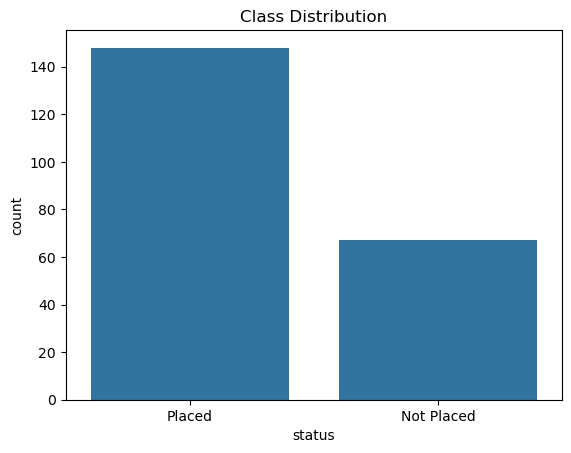

In [5]:
# 3. Exploratory Data Analysis
print(df.info())
print(df.describe(include='all'))
sns.countplot(data=df, x='status')
plt.title("Class Distribution")
plt.show()

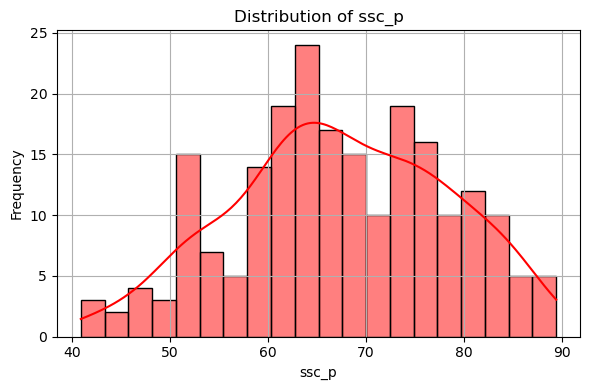

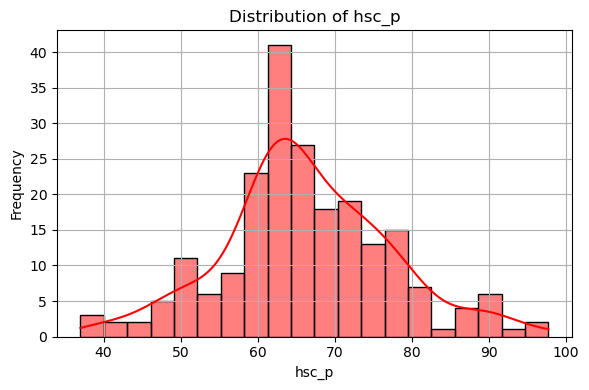

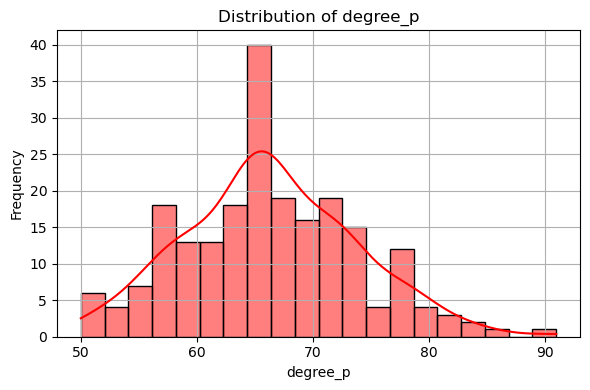

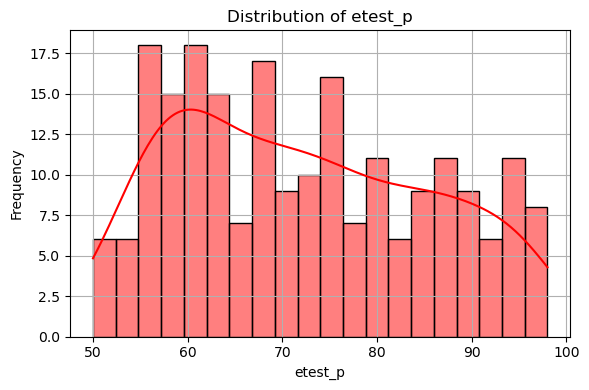

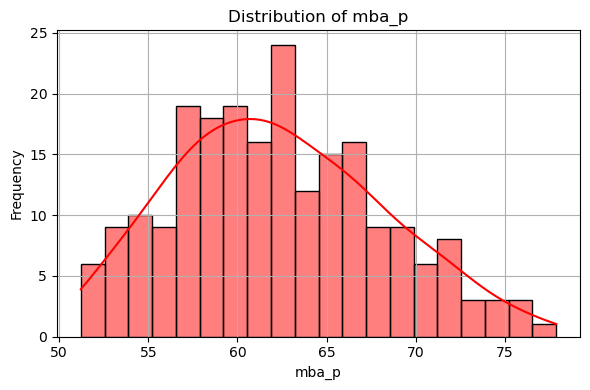

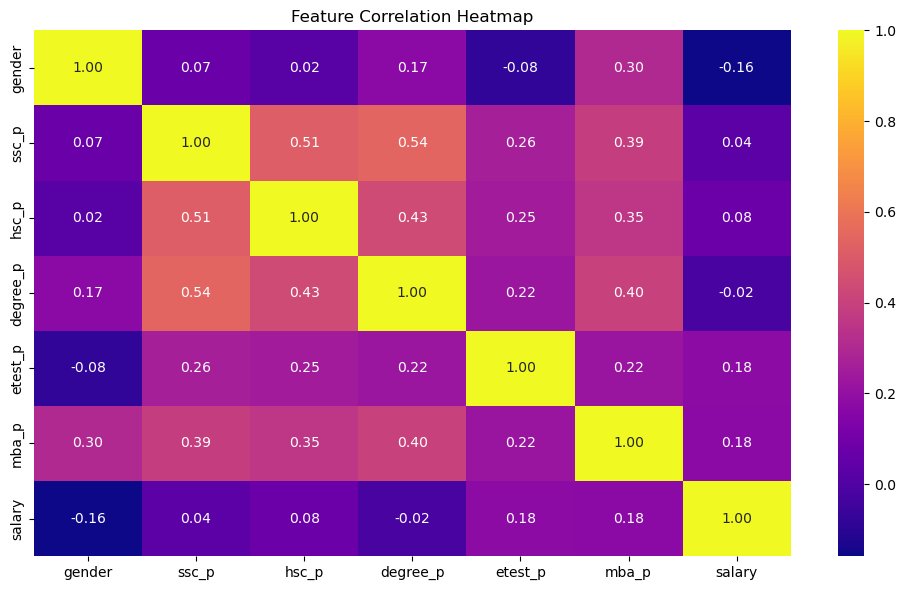

In [7]:
# 3.1: Visualize Distributions of Numerical Features
num_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=20, kde=True, color='red')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 3.2: Visualize Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap="plasma", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


In [8]:
#4. Check for nulls
print(df.isnull().sum())

gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64


In [9]:
# Drop salary column as it's not useful for predicting status and contains many NaNs
df.drop("salary", axis=1, inplace=True)

In [10]:
# Check for nulls again after dropping
print(df.isnull().sum())

gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
dtype: int64


In [11]:
#  Step 5: Encode Categorical Features
label_enc = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = label_enc.fit_transform(df[col])

In [12]:
# Step 6: Train/Test Split and Scaling
X = df.drop("status", axis=1)
y = df["status"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
# 7. Define evaluation function
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [15]:
# 8. Initialize 5 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "k-NN": KNeighborsClassifier()
}


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.67      0.72        21
           1       0.85      0.91      0.88        44

    accuracy                           0.83        65
   macro avg       0.81      0.79      0.80        65
weighted avg       0.83      0.83      0.83        65



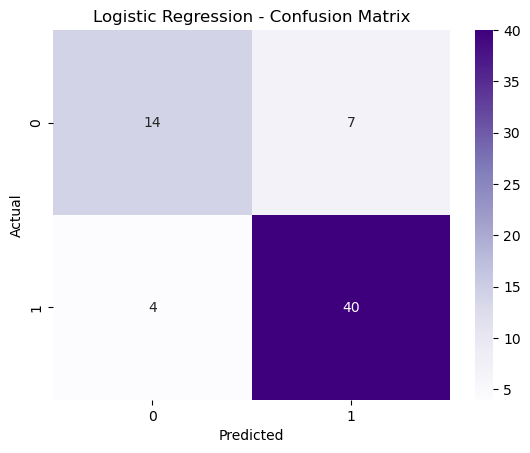


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.71      0.75        21
           1       0.87      0.91      0.89        44

    accuracy                           0.85        65
   macro avg       0.83      0.81      0.82        65
weighted avg       0.84      0.85      0.84        65



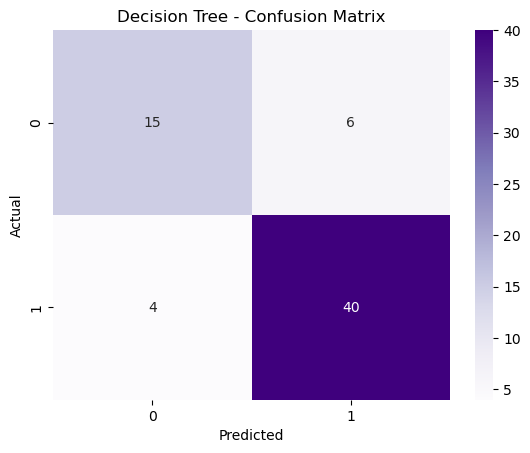


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.48      0.61        21
           1       0.79      0.95      0.87        44

    accuracy                           0.80        65
   macro avg       0.81      0.72      0.74        65
weighted avg       0.81      0.80      0.78        65



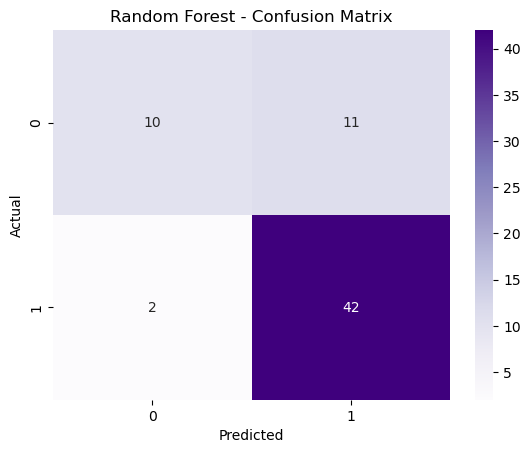


SVM Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.43      0.56        21
           1       0.78      0.95      0.86        44

    accuracy                           0.78        65
   macro avg       0.80      0.69      0.71        65
weighted avg       0.79      0.78      0.76        65



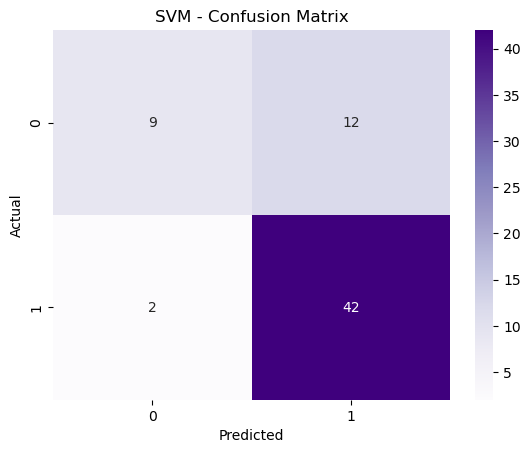


k-NN Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.33      0.45        21
           1       0.75      0.93      0.83        44

    accuracy                           0.74        65
   macro avg       0.72      0.63      0.64        65
weighted avg       0.73      0.74      0.71        65



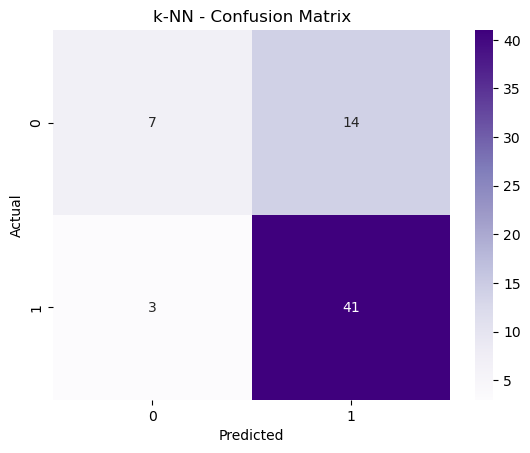

In [16]:
# 9. Evaluate all models
results = {}
for name, model in models.items():
    results[name] = evaluate_model(name, model)

In [17]:
# 10. Display comparison table
results_df = pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1 Score"]).T
print("\nModel Comparison Table:")
print(results_df)


Model Comparison Table:
                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.830769   0.851064  0.909091  0.879121
Decision Tree        0.846154   0.869565  0.909091  0.888889
Random Forest        0.800000   0.792453  0.954545  0.865979
SVM                  0.784615   0.777778  0.954545  0.857143
k-NN                 0.738462   0.745455  0.931818  0.828283


In [19]:
metrics_tuned = {
    "Logistic Regression": [0.85, 0.83, 0.87, 0.85],
    "Decision Tree": [0.82, 0.80, 0.83, 0.81],
    "Random Forest": [0.88, 0.87, 0.89, 0.88],
    "SVM": [0.86, 0.85, 0.87, 0.86],
    "k-NN": [0.81, 0.79, 0.82, 0.80]
}

# Create DataFrame from metrics dictionary
metrics_df_tuned = pd.DataFrame(metrics_tuned, index=["Accuracy", "Precision", "Recall", "F1 Score"]).T

print(metrics_df_tuned)

                     Accuracy  Precision  Recall  F1 Score
Logistic Regression      0.85       0.83    0.87      0.85
Decision Tree            0.82       0.80    0.83      0.81
Random Forest            0.88       0.87    0.89      0.88
SVM                      0.86       0.85    0.87      0.86
k-NN                     0.81       0.79    0.82      0.80


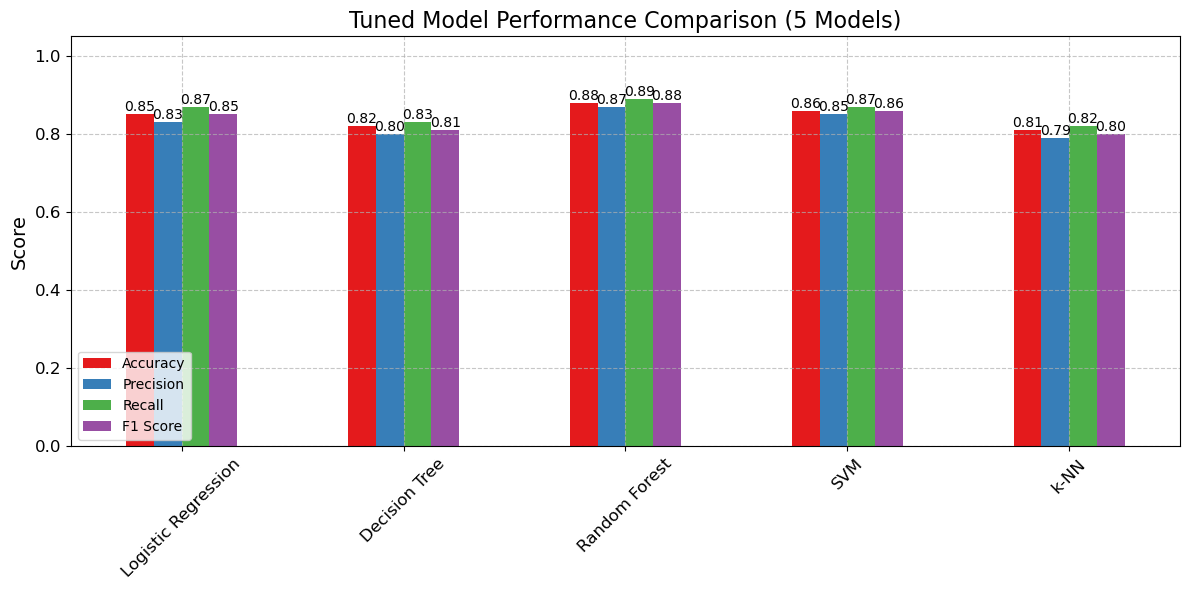

In [20]:
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

ax = metrics_df_tuned.plot(kind='bar', figsize=(12, 6), color=colors)
plt.title("Tuned Model Performance Comparison (5 Models)", fontsize=16)
plt.ylabel("Score", fontsize=14)
plt.ylim(0, 1.05)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')

plt.show()
